In [74]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np

In [75]:
df = pd.read_csv("../resources/sample_data/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [76]:
categories = pd.get_dummies(df.Species, dtype=int)
ohe_df = pd.concat([df, categories], axis=1)
ohe_df.drop(columns=["Species", "Id"], inplace=True)
ohe_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Iris-setosa,Iris-versicolor,Iris-virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


In [77]:
datasets = ohe_df.values
X = datasets[:, 0:4]
y = datasets[:, 4:7]

scaler = MinMaxScaler()
X_scale = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scale, y, test_size=0.3, random_state=42)

In [78]:
model = Sequential([
    Dense(64, input_shape=(4,)),
    Dropout(0.3),
    BatchNormalization(momentum=0.98),
    Dense(64, activation='relu'),

    Dense(32),
    Dropout(0.3),
    BatchNormalization(momentum=0.98),
    Dense(32, activation='relu'),

    Dense(16),
    Dropout(0.3),
    BatchNormalization(momentum=0.98),
    Dense(16, activation='relu'),

    Dense(8),
    Dropout(0.3),
    BatchNormalization(momentum=0.98),
    Dense(8, activation='relu'),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer="Adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

### Make callbacks

In [79]:
class StopAccuracy(Callback):
    def on_epoch_end(self, epoch, log={}):
        if log.get("accuracy") > 0.95 and log.get("loss") < 0.45:
            self.model.stop_training = True

stop_accuracy_callback = StopAccuracy()

In [80]:
model_history = model.fit(X_train, y_train, epochs=500, callbacks=[stop_accuracy_callback])

Epoch 1/500
4/4 [==============================] - 10s 13ms/step - loss: 1.1517 - accuracy: 0.3810
Epoch 2/500
4/4 [==============================] - 0s 11ms/step - loss: 1.0715 - accuracy: 0.4190
Epoch 3/500
4/4 [==============================] - 0s 10ms/step - loss: 1.0839 - accuracy: 0.4190
Epoch 4/500
4/4 [==============================] - 0s 9ms/step - loss: 1.0558 - accuracy: 0.4190
Epoch 5/500
4/4 [==============================] - 0s 10ms/step - loss: 1.0109 - accuracy: 0.4857
Epoch 6/500
4/4 [==============================] - 0s 9ms/step - loss: 1.0155 - accuracy: 0.4952
Epoch 7/500
4/4 [==============================] - 0s 10ms/step - loss: 1.0005 - accuracy: 0.5143
Epoch 8/500
4/4 [==============================] - 0s 9ms/step - loss: 0.9348 - accuracy: 0.4952
Epoch 9/500
4/4 [==============================] - 0s 9ms/step - loss: 0.9259 - accuracy: 0.6000
Epoch 10/500
4/4 [==============================] - 0s 10ms/step - loss: 0.9143 - accuracy: 0.5619
Epoch 11/500
4/4 [====

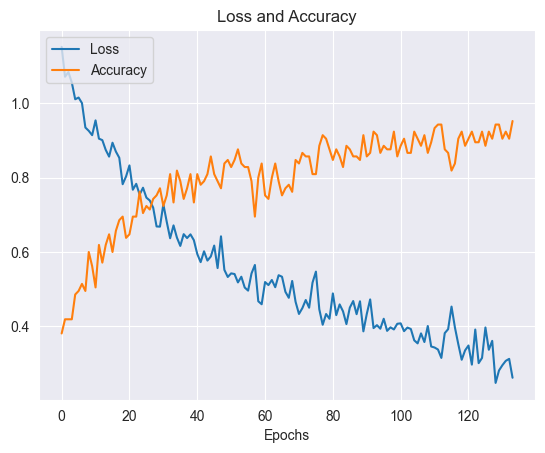

In [81]:
plt.plot(model.history.history["loss"])
plt.plot(model.history.history["accuracy"])
plt.title("Loss and Accuracy")
plt.xlabel("Epochs")
plt.legend(["Loss", "Accuracy"], loc="upper left")
plt.show()

In [82]:
model.evaluate(X_test, y_test)

2/2 [==============================] - 1s 22ms/step - loss: 0.1191 - accuracy: 1.0000


[0.11910001188516617, 1.0]

In [83]:
df[[df.columns[-1]] + df.columns[:-1].tolist()].drop("Id", axis=1).tail()

,Species,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
145,Iris-virginica,6.7,3.0,5.2,2.3
146,Iris-virginica,6.3,2.5,5.0,1.9
147,Iris-virginica,6.5,3.0,5.2,2.0
148,Iris-virginica,6.2,3.4,5.4,2.3
149,Iris-virginica,5.9,3.0,5.1,1.8


In [84]:
prediction_data = df.loc[149].drop(["Species", "Id"]).values.reshape(1, -1)
print(prediction_data)
# prediction_data = [[5.8, 3.5, 4.8, 1.3]]

[[5.9 3.0 5.1 1.8]]


In [87]:
pred = model.predict([scaler.transform(prediction_data)])

names = {idx: val for idx, val in enumerate(categories.columns)}
index = np.argmax(pred)
print(f"Prediction result is: {names[index]}")
pred

1/1 [==============================] - 0s 53ms/step
Prediction result is: Iris-virginica


array([[0.00181903, 0.26170138, 0.7364796 ]], dtype=float32)